# Анализ интернет-магазина одежды

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Анализ поведения пользователей

### Расчет DAU/MAU

In [ ]:
# DAU/MAU
mau_dau_ratio = pd.read_csv('mau_dau_ratio.csv')
mau_dau_ratio.head()

,month,mau,avg_dau,dau_mau_ratio
0,2019-01,11,0.0,0.0394
1,2019-02,25,1.0,0.0457
2,2019-03,42,2.0,0.0453
3,2019-04,44,2.0,0.0485
4,2019-05,79,3.0,0.0433


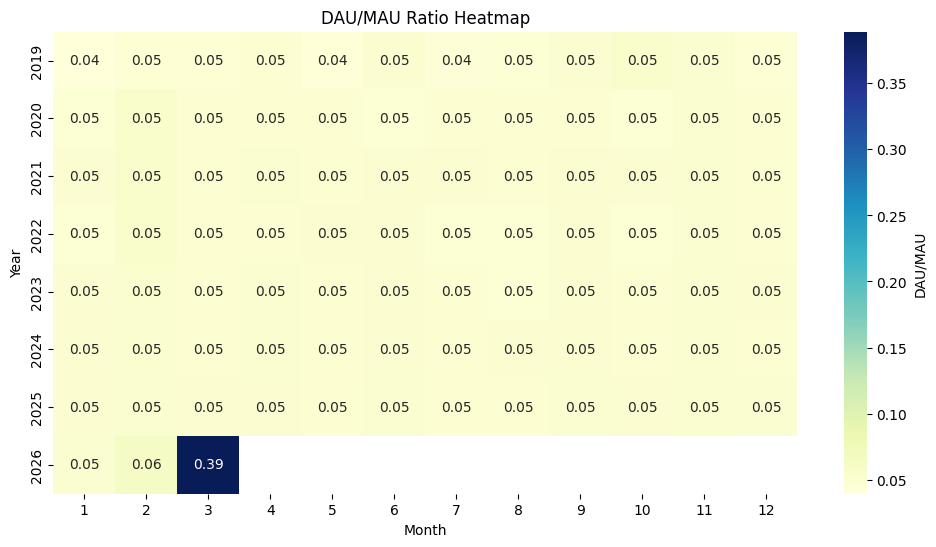

In [ ]:
# Преобразуем месяц в datetime
mau_dau_ratio['month'] = pd.to_datetime(mau_dau_ratio['month'])

# Создадим колонки для year и month_number
mau_dau_ratio['year'] = mau_dau_ratio['month'].dt.year
mau_dau_ratio['month_num'] = mau_dau_ratio['month'].dt.month

# Создадим pivot table для heatmap
heatmap_data = mau_dau_ratio.pivot(index='year', columns='month_num', values='dau_mau_ratio')
# Настроим порядок столбцов (1-12)
heatmap_data = heatmap_data.reindex(columns=range(1,13))

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap='YlGnBu', cbar_kws={'label': 'DAU/MAU'})
plt.title('DAU/MAU Ratio Heatmap')
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()

В течение большинства месяцев DAU/MAU держался на уровне ~0,05, что отражает низкую регулярность использования продукта.
В марте 2026 произошло резкое увеличение до 0,39, что свидетельствует о значительном росте вовлечённости пользователей.
Необходимо проверить маркетинговые кампании, продуктовые изменения и данные событий, чтобы определить источник аномалии.

In [ ]:
# аномалия
anom_index = mau_dau_ratio['dau_mau_ratio'].idxmax()

# вывод значений аномального месяца
anom_month = mau_dau_ratio.loc[anom_index]
print(f"Месяц: {anom_month['month']}")
print(f"MAU: {anom_month['mau']}")
print(f"Средний DAU: {anom_month['avg_dau']}")
print(f"DAU/MAU Ratio: {anom_month['dau_mau_ratio']}")

Месяц: 2026-03-01 00:00:00
MAU: 509
Средний DAU: 198.0
DAU/MAU Ratio: 0.389


### Retention пользователей по месяцам

In [ ]:
retention = pd.read_csv('retention.csv')
retention.head()

,cohort_month,month_number,active_users,cohort_size,retention_rate
0,2019-01-01,0,4,1107,0.0036
1,2019-01-01,1,24,1107,0.0217
2,2019-01-01,2,24,1107,0.0217
3,2019-01-01,3,18,1107,0.0163
4,2019-01-01,4,19,1107,0.0172


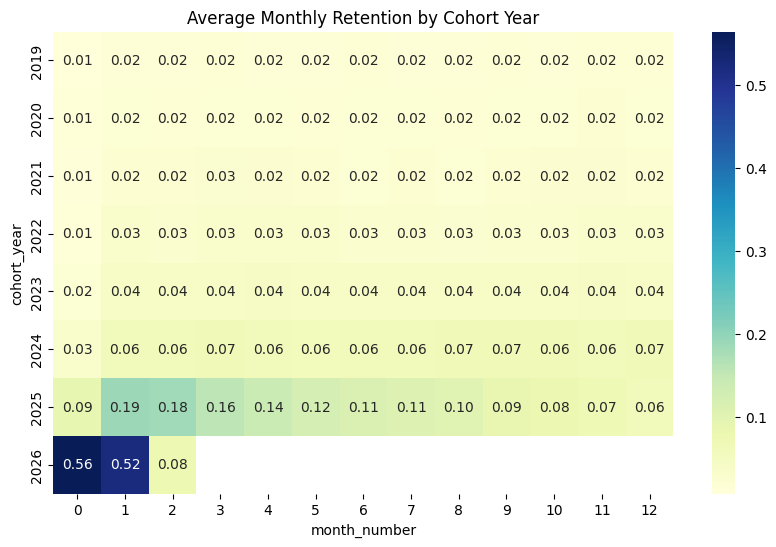

In [ ]:
retention['cohort_month'] = pd.to_datetime(retention['cohort_month']) # преобразуем в формат даты
retention['cohort_year'] = retention['cohort_month'].dt.year

# сгруппируем по годам чтобы график был более читаемый
yearly_matrix = retention.groupby(['cohort_year', 'month_number']) \
                  ['retention_rate'].mean() \
                  .reset_index()

pivot_year = yearly_matrix.pivot(
    index='cohort_year',
    columns='month_number',
    values='retention_rate'
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot_year, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Average Monthly Retention by Cohort Year")
plt.show()

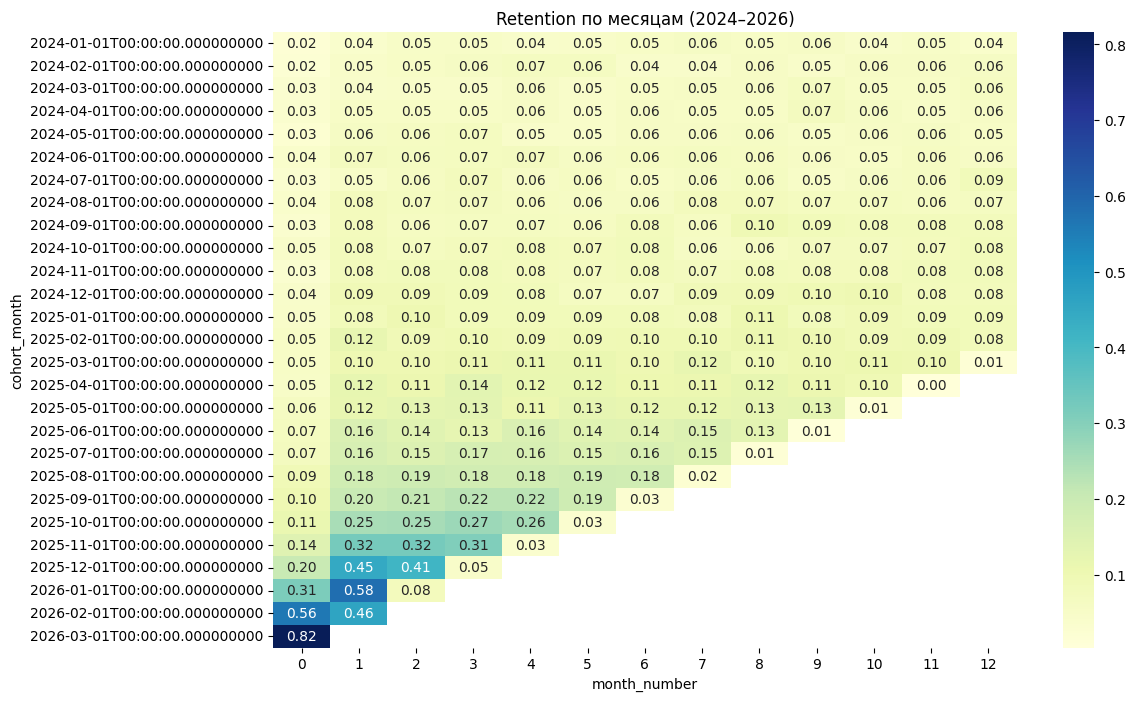

In [ ]:
# так как интереснее посмотреть на последние два года, сделаем более детальный хитмеп по этому времени
df_filtered = retention[retention['cohort_month'] >= '2024-01-01']

retention_matrix = df_filtered.pivot(
    index='cohort_month',
    columns='month_number',
    values='retention_rate'
)

plt.figure(figsize=(12,8))
sns.heatmap(retention_matrix, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Retention по месяцам (2024–2026)")
plt.show()

По графику отлично видно, что retention сильно вырос за последний год и достиг пиковых значений в марте 2026, что говорит о резком всплексе вовлеченности пользователей.

### LTV per user

In [ ]:
ltv = pd.read_csv('LTV.csv')
ltv.head()

,cohort_month,month_number,revenue,cohort_size,ltv_per_user
0,2019-01-01,0,170.680000,1107,0.15
1,2019-01-01,1,2210.640011,1107,2.00
2,2019-01-01,2,2668.279995,1107,2.41
3,2019-01-01,3,1226.440011,1107,1.11
4,2019-01-01,4,2467.219999,1107,2.23


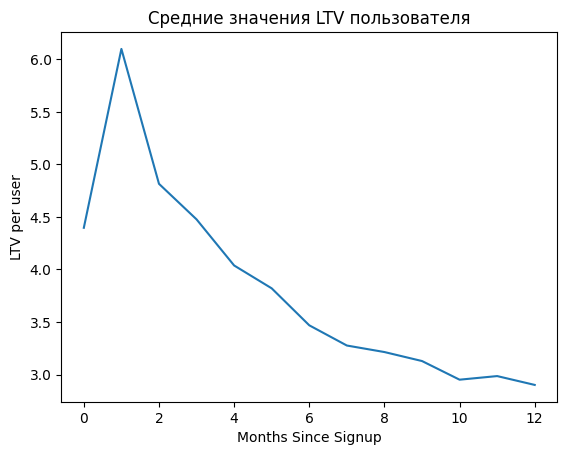

In [ ]:
ltv_curve = ltv.groupby('month_number')['ltv_per_user'].mean()

plt.plot(ltv_curve.index, ltv_curve.values)
plt.title("Cредние значения LTV пользователя")
plt.xlabel("Months Since Signup")
plt.ylabel("LTV per user")
plt.show()

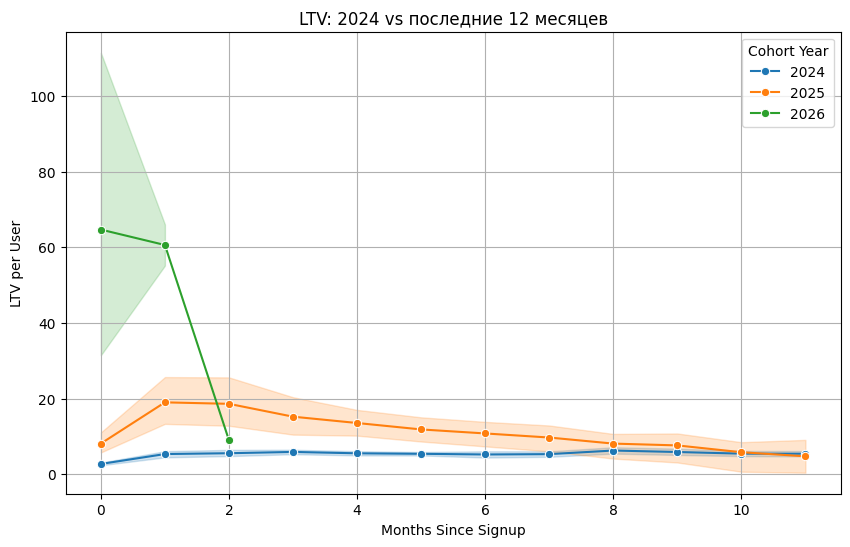

In [ ]:
ltv['cohort_month'] = pd.to_datetime(ltv['cohort_month'])

# оставляем только 2024 год и последние 12 месяцев (2025-03 до 2026-02) чтобы сравнить динамику
df_filtered = ltv[
    (ltv['cohort_month'].dt.year == 2024) |
    (ltv['cohort_month'] >= pd.to_datetime('2025-03-01'))
]

# берём только первые 12 месяцев жизни пользователей
df_filtered = df_filtered[df_filtered['month_number'] <= 11]

plt.figure(figsize=(10,6))
sns.lineplot(
    data=df_filtered,
    x='month_number',
    y='ltv_per_user',
    hue=df_filtered['cohort_month'].dt.year.astype(str),
    marker='o'
)
plt.title("LTV: 2024 vs последние 12 месяцев")
plt.xlabel("Months Since Signup")
plt.ylabel("LTV per User")
plt.legend(title="Cohort Year")
plt.grid(True)
plt.show()

In [ ]:
avg_ltv = df_filtered.groupby(df_filtered['cohort_month'].dt.year)['ltv_per_user'].mean()
print("Средний LTV за первые 12 месяцев:")
print(avg_ltv)

Средний LTV за первые 12 месяцев:
cohort_month
2024     5.370972
2025    12.629405
2026    54.063333
Name: ltv_per_user, dtype: float64


Пользователи 2026 года приносят в два раза больше выручки, чем 2024. Пользователи за первые 2 месяца 2026 года показывают пиковый рост LTV, что также совпадает с ростом retention и DAU/MAU ratio.

Новые пользователи становятся более ценнными за первые 12 месяцев жизни.

## Анализ продаж и дохода

### Выручка, средний чек, кол-во заказов

In [ ]:
revenue = pd.read_csv('revenue.csv')
revenue.head()

,month,total_orders,total_revenue,avg_item_price,avg_items_per_order,avg_order_value
0,2019-02,11,784.550013,39.227501,2.300000,71.322728
1,2019-03,15,1330.350003,70.018421,1.736842,88.690000
2,2019-04,18,2144.229983,71.474333,2.066667,119.123888
3,2019-05,20,2081.390009,80.053462,1.538462,104.069500
4,2019-06,23,2472.160001,88.291429,1.428571,107.485217


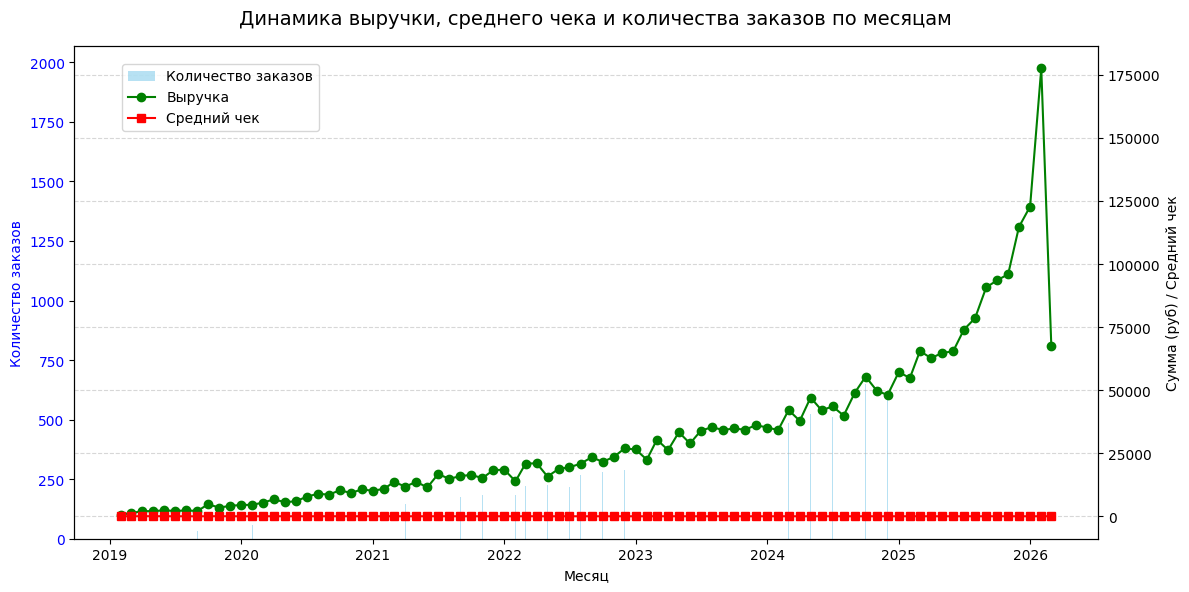

In [ ]:
revenue['month'] = pd.to_datetime(revenue['month'], format='%Y-%m')


fig, ax1 = plt.subplots(figsize=(12, 6))

# кол-во заказов по левой оси
ax1.bar(revenue['month'], revenue['total_orders'], color='skyblue', alpha=0.6, label='Количество заказов')
ax1.set_xlabel('Месяц')
ax1.set_ylabel('Количество заказов', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# revenue и avg_order_value по второй оси
ax2 = ax1.twinx()

ax2.plot(revenue['month'], revenue['total_revenue'], color='green', marker='o', label='Выручка')
ax2.plot(revenue['month'], revenue['avg_order_value'], color='red', marker='s', label='Средний чек')
ax2.set_ylabel('Сумма (руб) / Средний чек', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# заголовок и легенда
fig.suptitle('Динамика выручки, среднего чека и количества заказов по месяцам', fontsize=14)
fig.legend(loc='upper left', bbox_to_anchor=(0.1,0.9))

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Конверсия по месяцам


In [ ]:
conversion_rate = pd.read_csv('conversion_rate.csv')
conversion_rate.head()

,month,conversion_rate
0,2019-01,0.000000
1,2019-02,0.392857
2,2019-03,0.326087
3,2019-04,0.272727
4,2019-05,0.224719


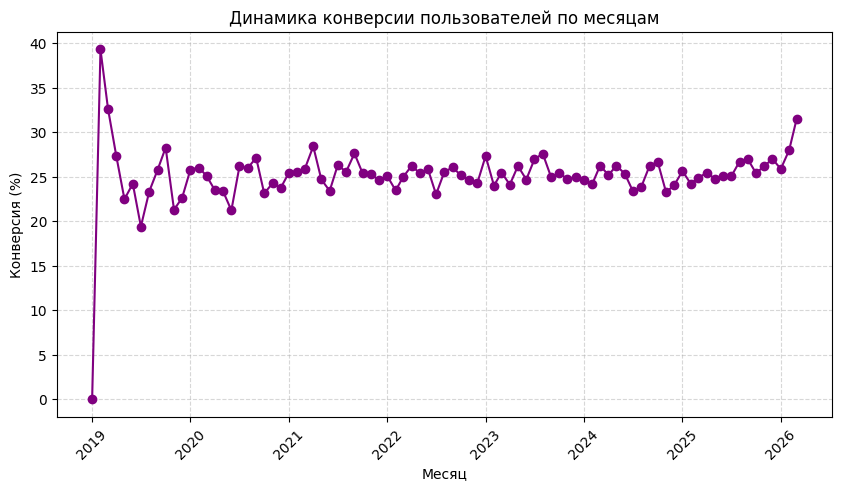

In [ ]:
conversion_rate['month'] = pd.to_datetime(conversion_rate['month'], format='%Y-%m')

plt.figure(figsize=(10,5))
plt.plot(conversion_rate['month'], conversion_rate['conversion_rate']*100, marker='o', color='purple')
plt.title('Динамика конверсии пользователей по месяцам')
plt.ylabel('Конверсия (%)')
plt.xlabel('Месяц')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.show()